# EDA — Market Data
Exploratory analysis of 5 years of daily price data across 12 tickers (Tech, Financials, ETFs).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Load data
prices = pd.read_csv("../data/processed/market_prices.csv", parse_dates=["date"])
metrics = pd.read_csv("../data/processed/analytics_metrics.csv", parse_dates=["date"])

print("Market prices shape:", prices.shape)
print("Analytics metrics shape:", metrics.shape)

Market prices shape: (15060, 9)
Analytics metrics shape: (15060, 13)


## 1. Basic Data Check

In [2]:
prices.head()

,date,ticker,open,high,low,close,adj_close,volume,category
0,2021-04-27,AAPL,135.009995,135.410004,134.110001,134.389999,130.895264,66015800,Technology
1,2021-04-28,AAPL,134.309998,135.020004,133.080002,133.580002,130.106323,107760100,Technology
2,2021-04-29,AAPL,136.470001,137.070007,132.449997,133.479996,130.008942,151101000,Technology
3,2021-04-30,AAPL,131.779999,133.559998,131.070007,131.460007,128.041458,109839500,Technology
4,2021-05-03,AAPL,132.039993,134.070007,131.830002,132.539993,129.093384,75135100,Technology


In [3]:
# Tickers, date range, and row counts
print("Tickers:", sorted(prices["ticker"].unique()))
print("Date range:", prices["date"].min().date(), "→", prices["date"].max().date())
print("\nRows per ticker:")
print(prices.groupby("ticker").size().sort_values(ascending=False))

Tickers: ['AAPL', 'AMZN', 'BAC', 'GOOGL', 'GS', 'JPM', 'MS', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'XLF']
Date range: 2021-04-27 → 2026-04-24

Rows per ticker:
ticker
AAPL     1255
AMZN     1255
BAC      1255
GOOGL    1255
GS       1255
JPM      1255
MS       1255
MSFT     1255
NVDA     1255
QQQ      1255
SPY      1255
XLF      1255
dtype: int64


In [4]:
# Missing values check
print("Missing values:\n")
print(prices.isnull().sum())

Missing values:

date         0
ticker       0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
category     0
dtype: int64


## 2. Closing Price Trends

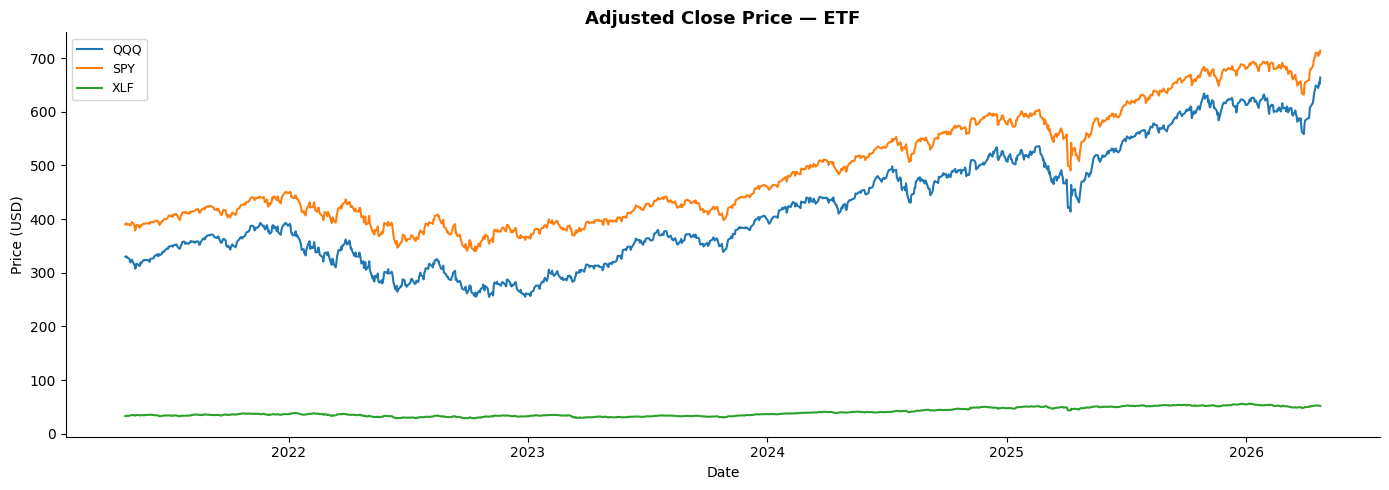

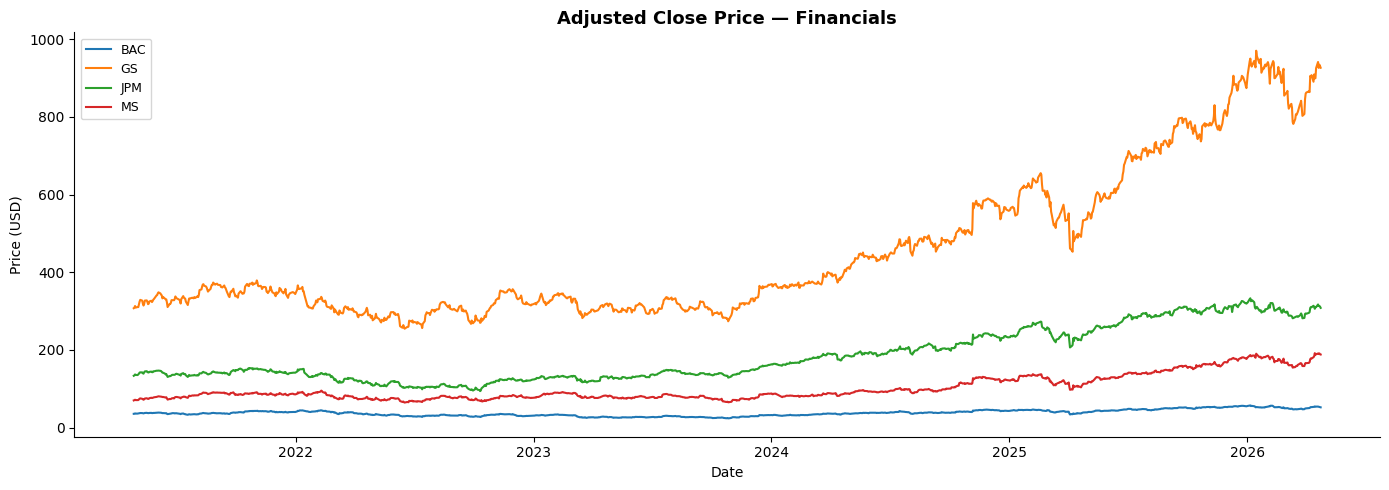

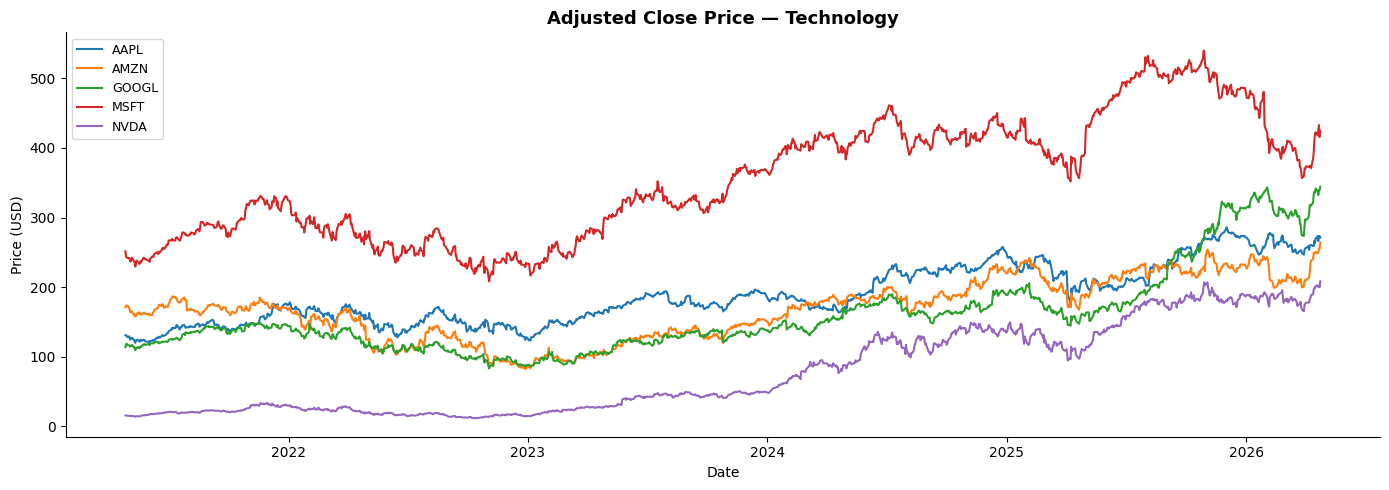

In [5]:
categories = prices["category"].unique()

for cat in sorted(categories):
    subset = prices[prices["category"] == cat]
    tickers = subset["ticker"].unique()

    fig, ax = plt.subplots()
    for ticker in tickers:
        df = subset[subset["ticker"] == ticker]
        ax.plot(df["date"], df["adj_close"], label=ticker, linewidth=1.5)

    ax.set_title(f"Adjusted Close Price — {cat}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend(loc="upper left", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.show()

## 3. Cumulative Returns — All Tickers

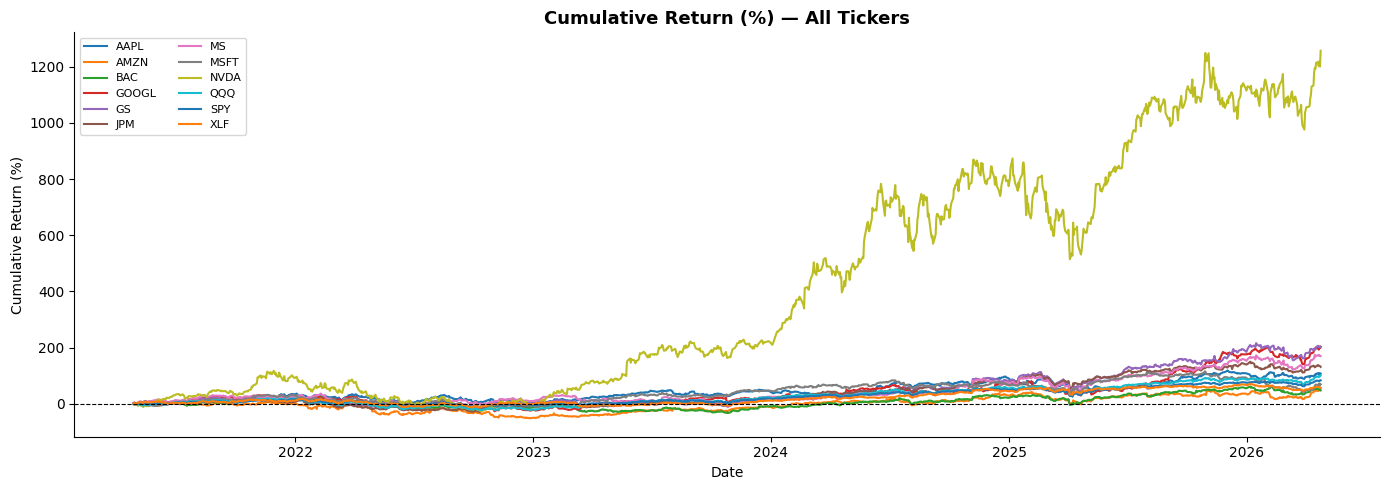

In [6]:
fig, ax = plt.subplots()

for ticker, group in metrics.groupby("ticker"):
    group = group.sort_values("date")
    ax.plot(group["date"], group["cumulative_return"] * 100, label=ticker, linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Return (%) — All Tickers", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 4. Daily Return Distribution

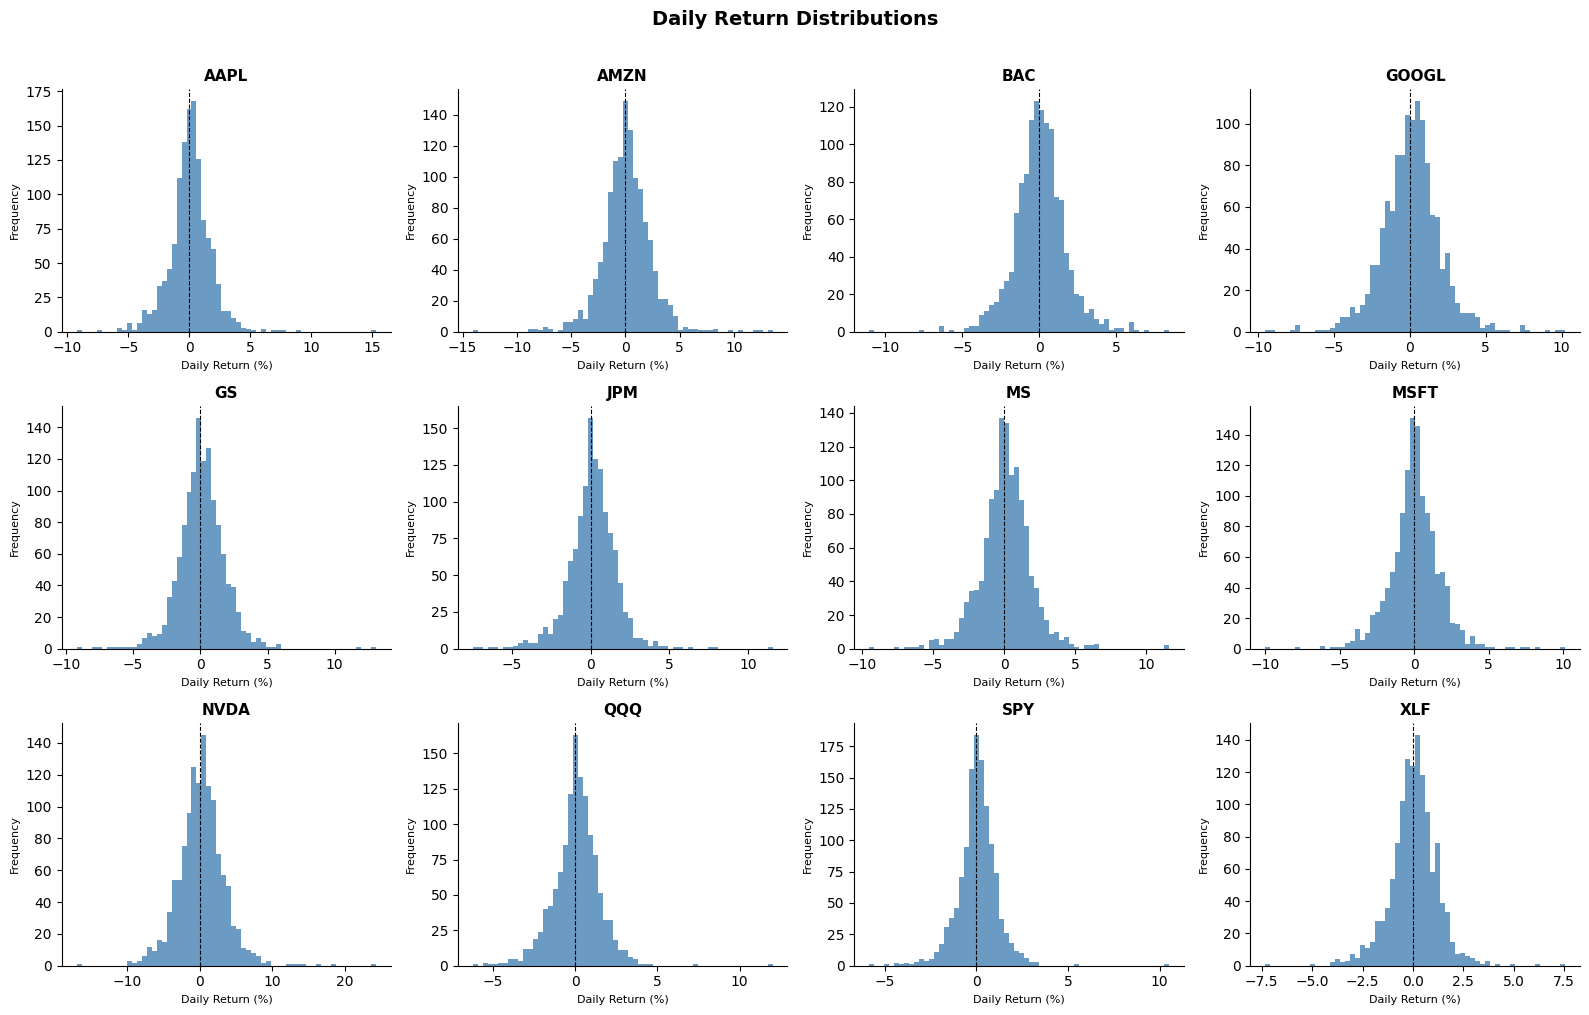

In [7]:
tickers = sorted(metrics["ticker"].unique())
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    data = metrics[metrics["ticker"] == ticker]["daily_return"].dropna() * 100
    axes[i].hist(data, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[i].set_title(ticker, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Daily Return (%)", fontsize=8)
    axes[i].set_ylabel("Frequency", fontsize=8)

plt.suptitle("Daily Return Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation Matrix

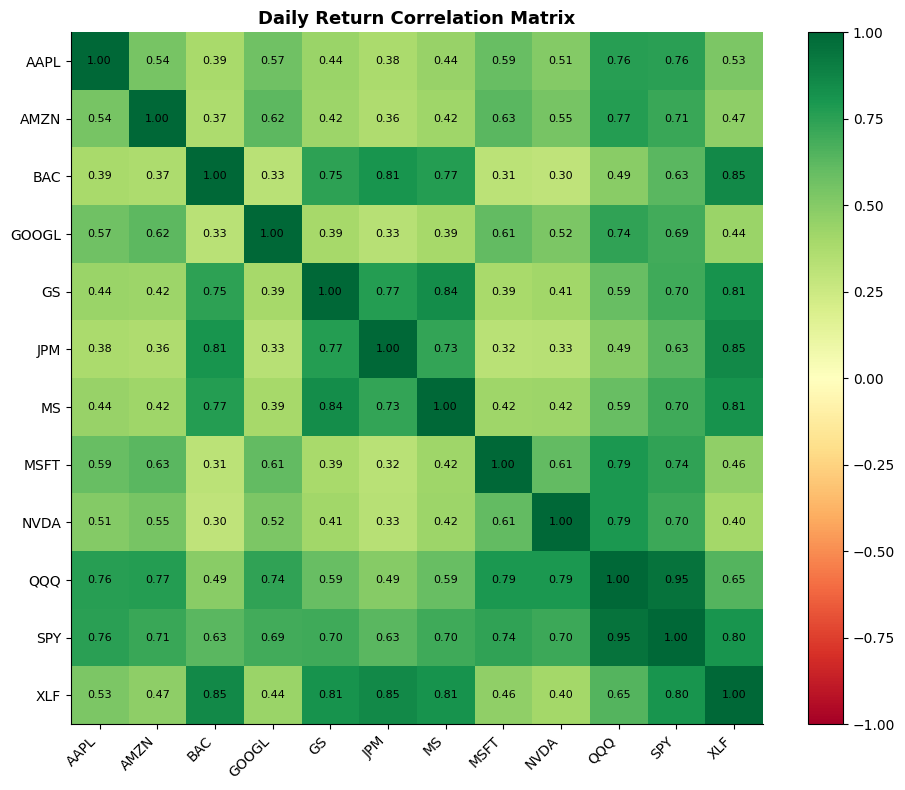

In [8]:
import numpy as np

pivot = metrics.pivot_table(index="date", columns="ticker", values="daily_return")
corr = pivot.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

tickers_list = corr.columns.tolist()
ax.set_xticks(range(len(tickers_list)))
ax.set_yticks(range(len(tickers_list)))
ax.set_xticklabels(tickers_list, rotation=45, ha="right")
ax.set_yticklabels(tickers_list)

for i in range(len(tickers_list)):
    for j in range(len(tickers_list)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Daily Return Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()